# 시도 지역사회 건강부담 분석

2014~2018년 시도별 암 발생률과 인구·고령화·흡연·산업구조를 결합해 지역 단위 건강부담을 탐색한다. 결과는 통계적 연관성으로 해석하며 인과관계를 주장하지 않는다.

## 분석 기준과 출처

- 공간 단위: 시도(17개 광역자치단체)
- 기간: 2014~2018년
- 핵심 입력: `data/derived/regional_health_burden_2014_2018_v2.csv`
- 순위·프로필: `data/derived/regional_health_burden_ranked_2014_2018.csv`
- 상관표: `data/derived/regional_health_burden_correlations_2014_2018.csv`

이 파일들은 KOSIS·질병관리청 자료를 시도 단위로 집계한 파생본이며 원본은 수정하지 않는다.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR']
installed = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

DATA = Path('../data/derived')
profile = pd.read_csv(DATA / 'regional_health_burden_2014_2018_v2.csv')
ranked = pd.read_csv(DATA / 'regional_health_burden_ranked_2014_2018.csv')
correlations = pd.read_csv(DATA / 'regional_health_burden_correlations_2014_2018.csv')
profile.head()

,REGION_CODE,REGION_NAME,PERIOD_START,PERIOD_END,CANCER_CASES_2014_2018,CANCER_CRUDE_RATE_PER_100K,CANCER_ASR_PER_100K,SMOKING_CRUDE_RATE_AVG_PCT,SMOKING_ASR_AVG_PCT,SMOKING_YEARS,...,BUSINESSES_PER_1000_PEOPLE,CANCER_ASR_Z,SMOKING_ASR_Z,AGING_RATE_Z,MANUFACTURING_SHARE_Z,EXPLORATORY_BURDEN_Z,EXPLORATORY_BURDEN_SCORE_0_100,DATA_COMPLETENESS_PCT,SPATIAL_UNIT,INTERPRETATION
0,11,서울특별시,2014,2018,215807,439.9,504.2,19.38,20.42,5,...,44.701610,0.198828,-1.227839,-0.428778,-1.652440,-0.485930,34.975559,100.0,시도,탐색적 지역 단위 통계 연관성; 개인 인과관계 아님
1,21,부산광역시,2014,2018,88463,511.5,525.9,20.68,21.92,5,...,39.489405,2.175854,-0.107227,0.301544,-0.565102,0.790057,100.000000,100.0,시도,탐색적 지역 단위 통계 연관성; 개인 인과관계 아님
2,22,대구광역시,2014,2018,56890,461.6,513.9,20.60,21.60,5,...,37.644318,1.082568,-0.346291,-0.320689,-0.151718,0.138529,66.798068,100.0,시도,탐색적 지역 단위 통계 연관성; 개인 인과관계 아님
3,23,인천광역시,2014,2018,59839,412.8,499.7,23.56,23.98,5,...,32.007502,-0.211154,1.431746,-0.989912,0.414092,0.076893,63.657088,100.0,시도,탐색적 지역 단위 통계 연관성; 개인 인과관계 아님
4,24,광주광역시,2014,2018,29098,398.5,489.2,19.92,21.00,5,...,39.388033,-1.167780,-0.794536,-0.794740,-0.661034,-0.919019,12.905301,100.0,시도,탐색적 지역 단위 통계 연관성; 개인 인과관계 아님


In [2]:
summary = pd.DataFrame({
    '공간 단위': [profile['SPATIAL_UNIT'].iloc[0]],
    '지역 수': [profile['REGION_NAME'].nunique()],
    '기준 기간': [f"{profile['PERIOD_START'].min()}~{profile['PERIOD_END'].max()}"],
    '완전 관측 지역 수': [(profile['DATA_COMPLETENESS_PCT'] == 100).sum()],
})
summary

,공간 단위,지역 수,기준 기간,완전 관측 지역 수
0,시도,17,2014~2018,17


In [3]:
display(ranked.sort_values('NON_POWER_HEALTH_BURDEN_SCORE_0_100', ascending=False)[[
    'REGION_NAME', 'CANCER_ASR_PER_100K', 'SMOKING_ASR_AVG_PCT',
    'AGING_RATE_AVG_PCT', 'MANUFACTURING_EMPLOYMENT_SHARE_AVG_PCT',
    'NON_POWER_HEALTH_BURDEN_SCORE_0_100', 'NON_POWER_BURDEN_TIER'
]])

,REGION_NAME,CANCER_ASR_PER_100K,SMOKING_ASR_AVG_PCT,AGING_RATE_AVG_PCT,MANUFACTURING_EMPLOYMENT_SHARE_AVG_PCT,NON_POWER_HEALTH_BURDEN_SCORE_0_100,NON_POWER_BURDEN_TIER
1,부산광역시,525.9,21.92,14.985538,18.053037,100.000000,높음
11,충청남도,508.2,23.28,16.547362,39.005035,98.270383,높음
14,경상북도,501.1,23.40,18.109532,37.271860,97.211289,높음
13,전라남도,502.5,21.68,20.785490,20.787288,91.950010,높음
10,충청북도,503.4,23.22,15.080338,35.753141,82.186311,높음
12,전라북도,503.8,21.38,18.062212,22.099428,75.500728,높음
9,강원도,481.5,24.08,17.169848,12.093140,70.451059,중간
15,경상남도,508.9,21.90,14.095296,37.998403,68.646378,중간
2,대구광역시,513.9,21.60,13.021291,22.757346,66.798068,중간
3,인천광역시,499.7,23.98,10.908708,29.196269,63.657088,중간


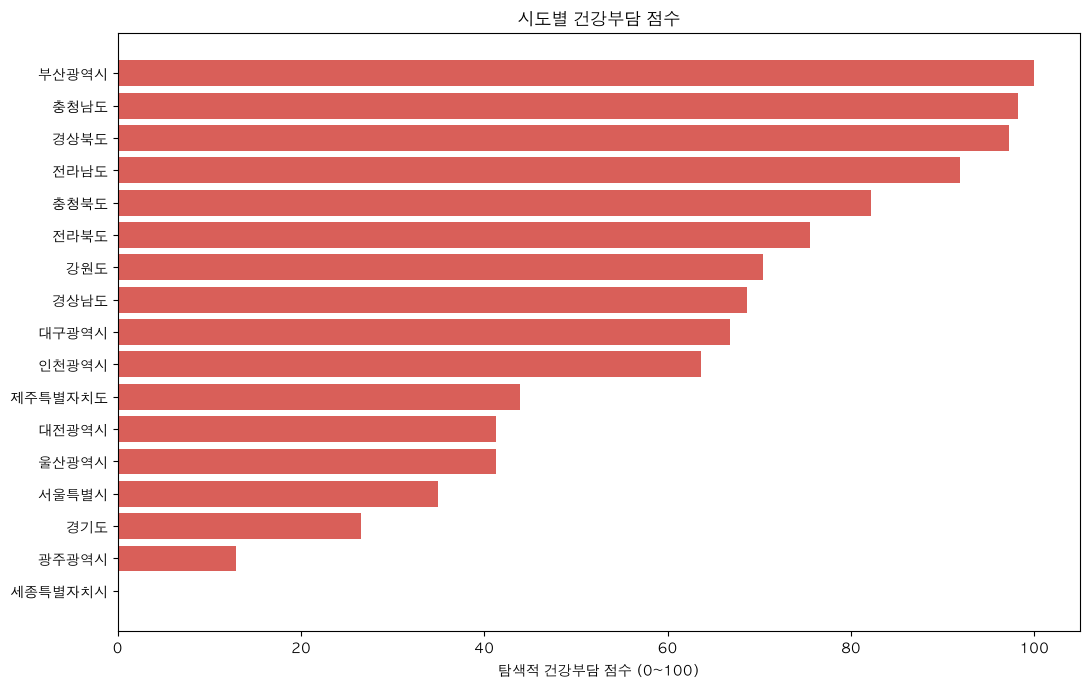

In [4]:
top = ranked.sort_values('NON_POWER_HEALTH_BURDEN_SCORE_0_100', ascending=False).copy()
plt.figure(figsize=(11, 7))
plt.barh(top['REGION_NAME'][::-1], top['NON_POWER_HEALTH_BURDEN_SCORE_0_100'][::-1], color='#d95f59')
plt.xlabel('탐색적 건강부담 점수 (0~100)')
plt.title('시도별 건강부담 점수')
plt.tight_layout()
plt.show()

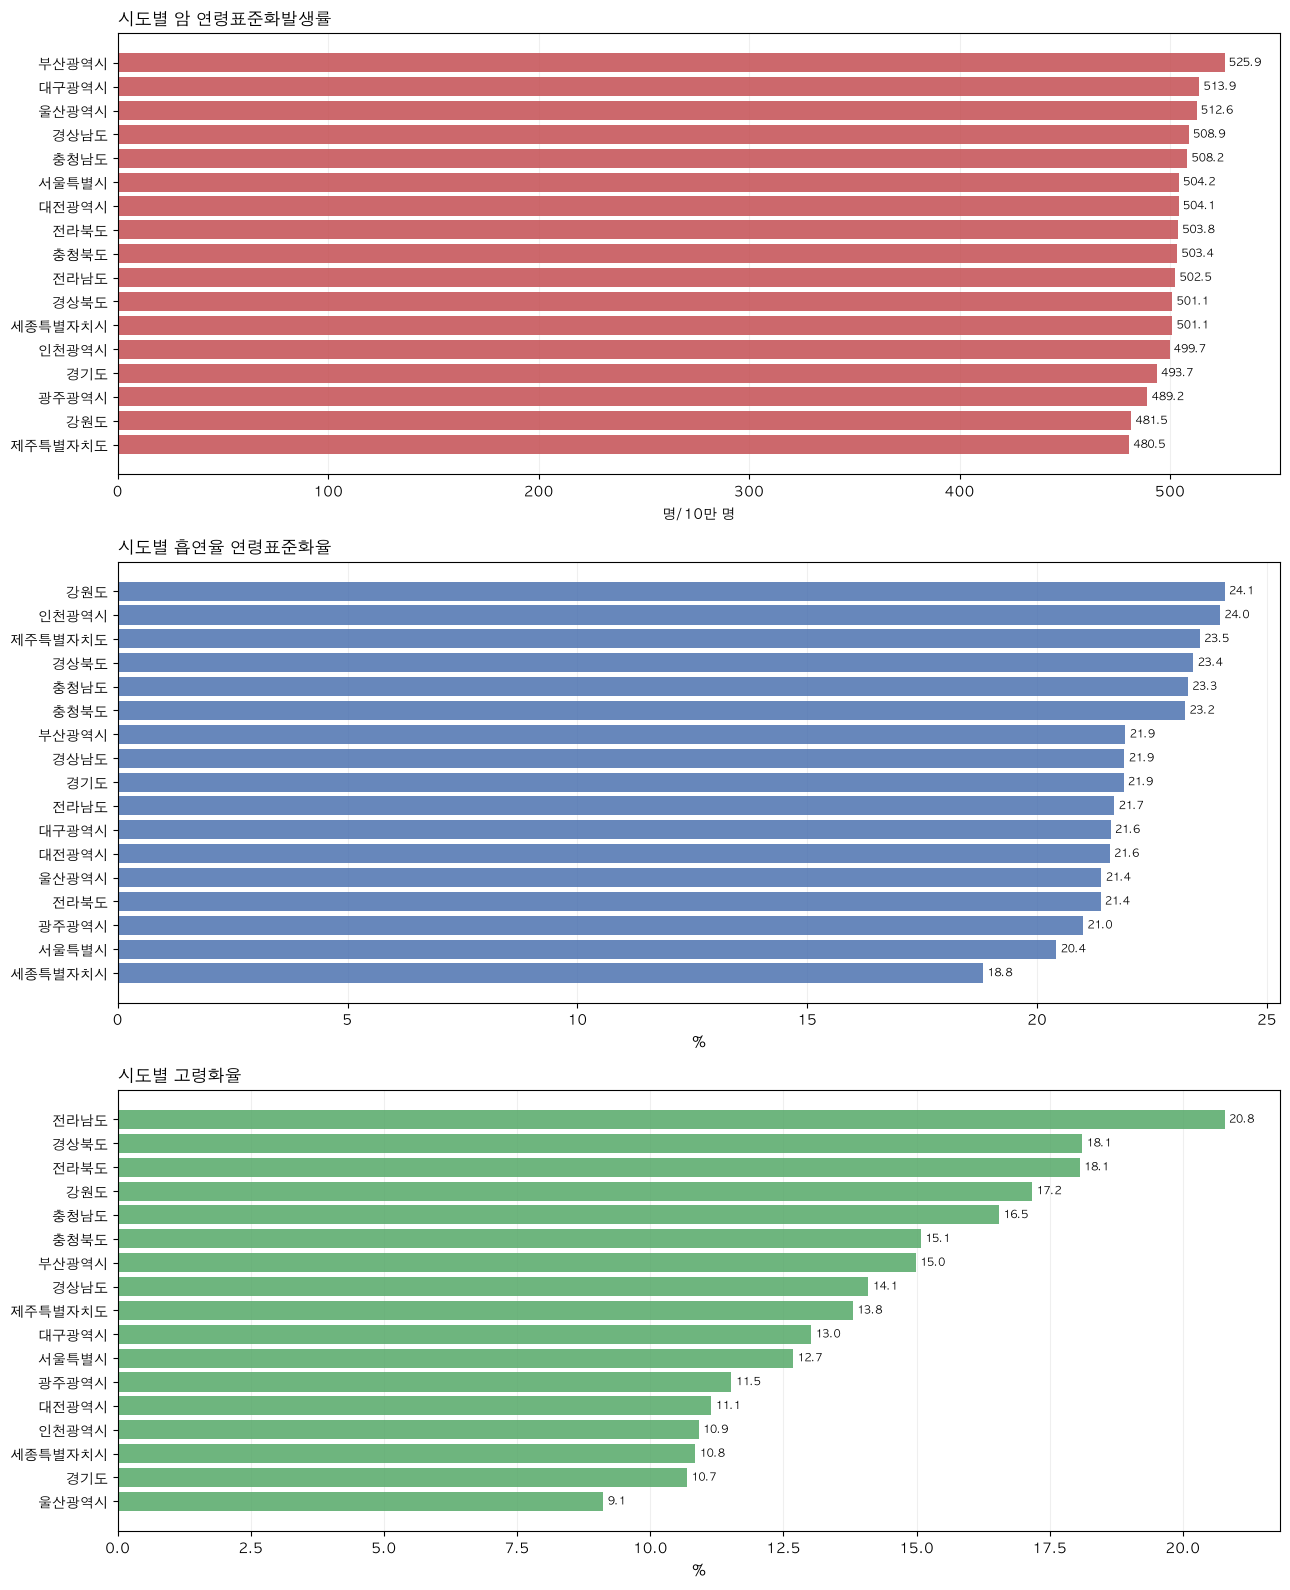

In [5]:
# 17개 시도의 지역명이 겹치지 않도록 산점도 대신 지표별 순위 막대그래프로 표시한다.
factor_specs = [
    ("CANCER_ASR_PER_100K", "암 연령표준화발생률", "#c44e52", "명/10만 명"),
    ("SMOKING_ASR_AVG_PCT", "흡연율 연령표준화율", "#4c72b0", "%"),
    ("AGING_RATE_AVG_PCT", "고령화율", "#55a868", "%"),
]
fig, axes = plt.subplots(3, 1, figsize=(13, 16))
for ax, (column, title, color, unit) in zip(axes, factor_specs):
    chart = profile.sort_values(column, ascending=True).dropna(subset=[column])
    bars = ax.barh(chart["REGION_NAME"], chart[column], color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
    ax.set_title(f"시도별 {title}", loc="left")
    ax.set_xlabel(unit)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [6]:
correlations

,OUTCOME,FACTOR,FACTOR_COLUMN,N_REGIONS,PEARSON_R,SPEARMAN_RHO,INTERPRETATION
0,모든 암 연령표준화발생률,현재흡연율 연령표준화율 평균,SMOKING_ASR_AVG_PCT,17,-0.298829,-0.295524,시도 단위 탐색적 연관성; 인과관계 또는 개인 위험으로 해석하지 않음
1,모든 암 연령표준화발생률,65세 이상 인구 비율 평균,AGING_RATE_AVG_PCT,17,-0.026153,0.003679,시도 단위 탐색적 연관성; 인과관계 또는 개인 위험으로 해석하지 않음
2,모든 암 연령표준화발생률,제조업 종사자 비중 평균,MANUFACTURING_EMPLOYMENT_SHARE_AVG_PCT,17,0.383188,0.340895,시도 단위 탐색적 연관성; 인과관계 또는 개인 위험으로 해석하지 않음


## 해석 주의

- 이 Notebook은 시군구가 아닌 시도 단위로 집계된 17개 지역을 비교한다.
- 건강부담 점수는 암·흡연·고령화 관련 지표를 결합한 탐색적 상대점수다.
- 산업구조는 보조 설명변수이며, 결과는 지역 단위 통계적 연관성이지 개인 수준 인과관계가 아니다.
- 시도 단위 관측 수가 17개이므로 상관계수는 탐색적으로만 해석한다.